In [21]:
import importlib
import pandas as pd
from itables import show
from src.A_Data_analysis import fleet_analysis
from src.A_Data_analysis import assignment_analysis
from src.A_Data_analysis import productivity_analysis
from src.A_Data_analysis import productivity_analysis
from src.B_Model_fitting import retirement_prio
# importlib.reload(fleet_analysis)
# importlib.reload(assignment_analysis)
# importlib.reload(productivity_analysis)
# importlib.reload(retirement_prio)

['C:\\Users\\p.viry\\PycharmProjects\\Thesis_models\\.venv\\Scripts\\python313.zip', 'C:\\Users\\p.viry\\AppData\\Local\\Programs\\Python\\Python313\\DLLs', 'C:\\Users\\p.viry\\AppData\\Local\\Programs\\Python\\Python313\\Lib', 'C:\\Users\\p.viry\\AppData\\Local\\Programs\\Python\\Python313', 'C:\\Users\\p.viry\\PycharmProjects\\Thesis_models\\.venv', '', 'C:\\Users\\p.viry\\PycharmProjects\\Thesis_models\\.venv\\Lib\\site-packages']


<module 'src.A_Data_analysis.productivity_analysis' from 'C:\\Users\\p.viry\\PycharmProjects\\Thesis_models\\src\\A_Data_analysis\\productivity_analysis.py'>

# Fleet model

In [2]:
db_full = pd.read_excel('D:\p.viry\Documents\Travail_recherche\Data\TAA\TAA_fleet/fleet_extract_treated_final_analysis.xlsx')
db_full['Aircraft Type'] = db_full['Type']+' '+db_full['Model'].astype(str)

### Possibility to add filters on the aircraft size, aircraft model, etc...
db_selec = db_full[['Aircraft Type','Engine', 'Delivery Date', 'Status', 'Date']].rename(columns={'Date':'Event Date'})
db_r = fleet_analysis.retirement_ranking(db_selec)

In [4]:
db_r['Aircraft Type'].unique()

array(['Vickers Viscount 600', 'Vickers Viscount 700',
       'Vickers Viscount 800', 'Lockheed Electra L188 L188A',
       'Boeing 707 100B', 'Boeing 707 200', 'Caravelle S210 1',
       'Fokker F27 100', 'Fairchild FH27 F27A', 'MDC DC8 10',
       'MDC DC8 20', 'Boeing 707 300', 'MDC DC8 50',
       'Lockheed Electra L188 L188C', 'Caravelle S210 3',
       'Boeing 720 030B', 'Fairchild FH27 F27', 'Boeing 707 100',
       'MDC DC8 40', 'MDC DC8 30', 'Fokker F27 200', 'Boeing 707 400',
       'Boeing 720 050B', 'Convair 580/640 (CV34) 580',
       'Caravelle S210 6N', 'MDC DC8 50JT', 'Boeing 720 20',
       'Ilyushin IL18 18D', 'HP Herald 200', 'Boeing 720 040B',
       'BAe 748 (H748) 1A', 'Boeing 727 100',
       'Vickers Vanguard (V900) 900', 'BAe Trident 1E', 'BAe Trident 1C',
       'Ilyushin IL18 18V', 'BAe BAC 1-11 200', 'MDC DC9 10',
       'Namco YS11 100', 'Convair 580/640 (CV34) 640', 'DHC-5 5A',
       'DHC-6 100', 'Fokker F27 400', 'BAe 748 (H748) C1',
       'Caravelle S2

## Data analysis

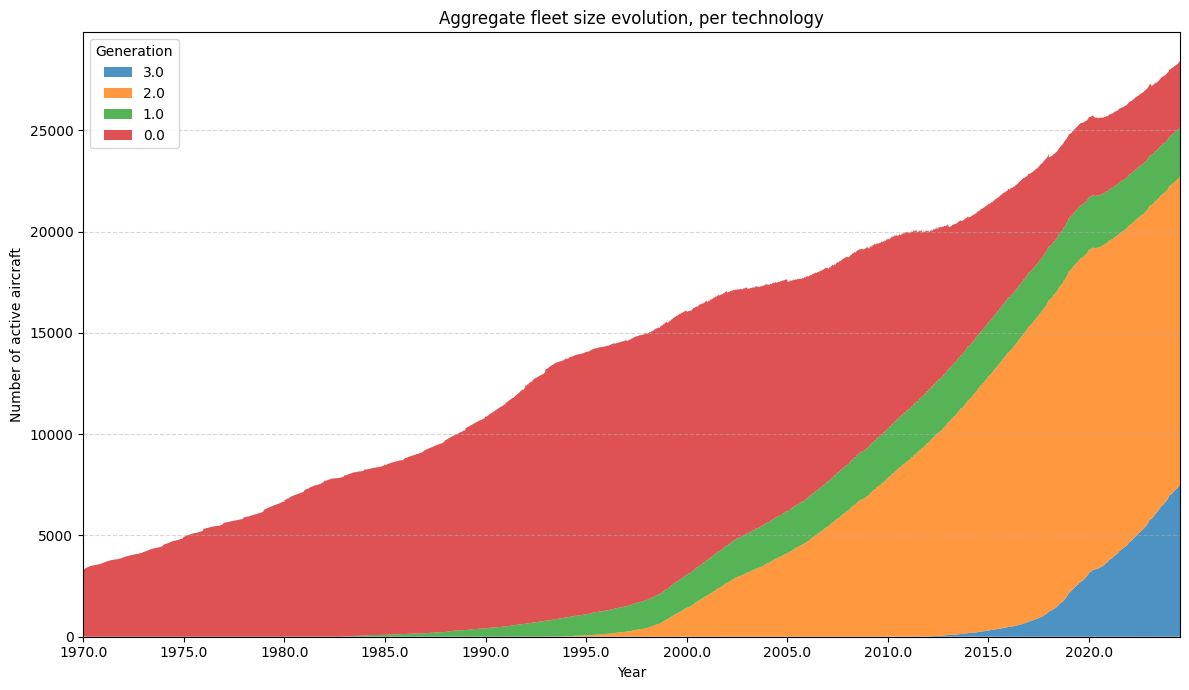

In [58]:
fleet_analysis.visu_fleet(db_selec)

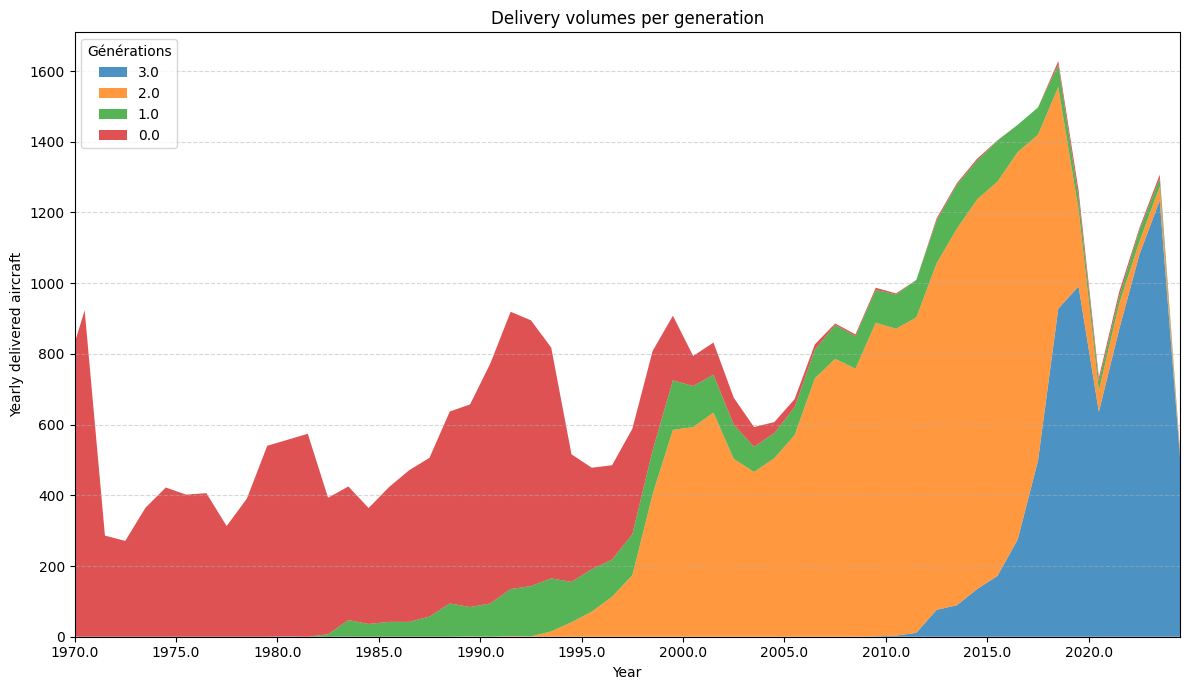

In [59]:
fleet_analysis.visu_prod(db_selec, reso = 1)

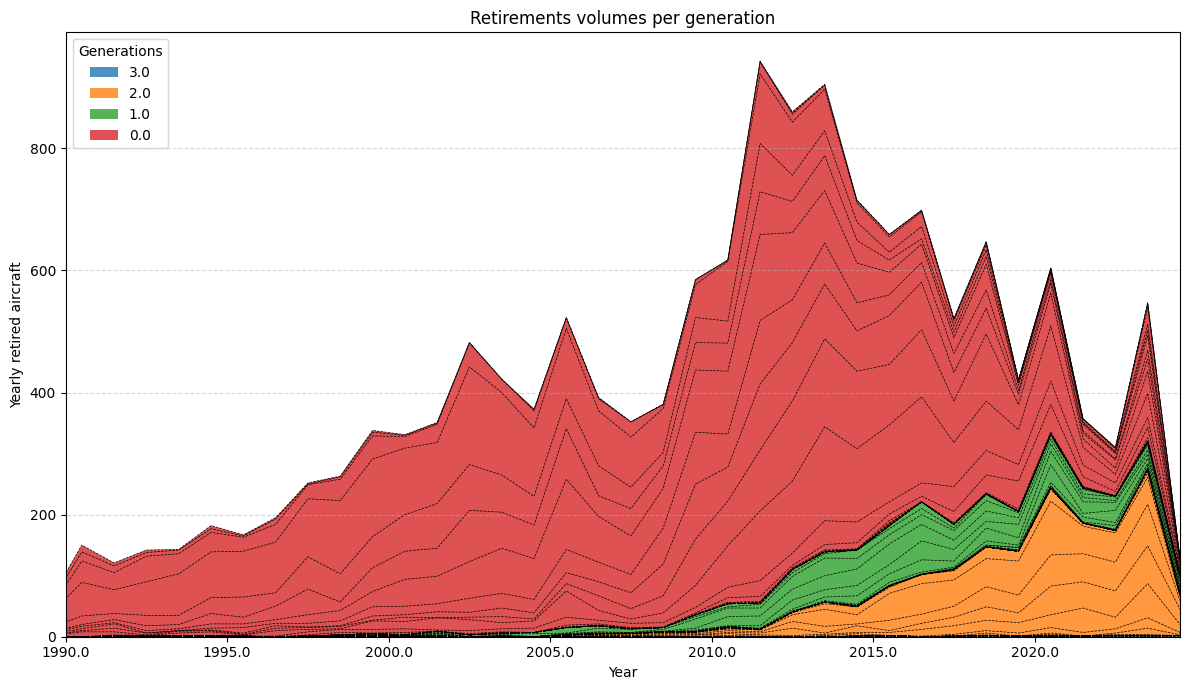

In [87]:
fleet_analysis.visu_retirements(db_selec, reso_1 = 1, reso_2 = 3)

## Model training

In [16]:
df_stat = retirement_prio.setting_df(db_r)
show(df_stat)

Loading ITables v2.6.2 from the internet... (need help?)


0: -187690.93842230673, -175361.1886406581, -171674.74481219405, -169044.74251489455, -167360.24989506177, -166510.76645867102, -165965.19420838103, -165313.12073680715, -164875.1830896789, -164537.51548214265, -164279.49214900474, -163982.14651809508, -163832.92653737488, -163590.55151282906, -163470.93428211837, -163268.18698046656, -163166.38372455016, -162994.87234074017, -162906.61607281468, -162759.69265671453, -162682.2722400567, -162546.5898541439, -162312.12105098355, reduction needed
-162083.49113660803, -162001.67650509012, -161110.55267339037, reduction needed
-161105.27577727445, -161065.430948946, -161014.17342745594, -160773.6025539146, 1: -160765.84760258062, -160714.48488281452, -160645.54233709106, reduction needed
-160629.9656793242, -160617.6179268171, reduction needed
-160599.72125385082, -160590.75783276444, -160583.6341723213, -160570.39671060134, reduction needed
-160559.47695757548, -160551.92906012697, -160545.67007127186, -160534.51400024208, reduction needed

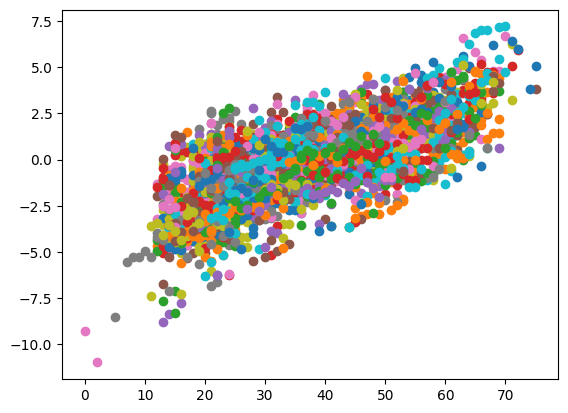

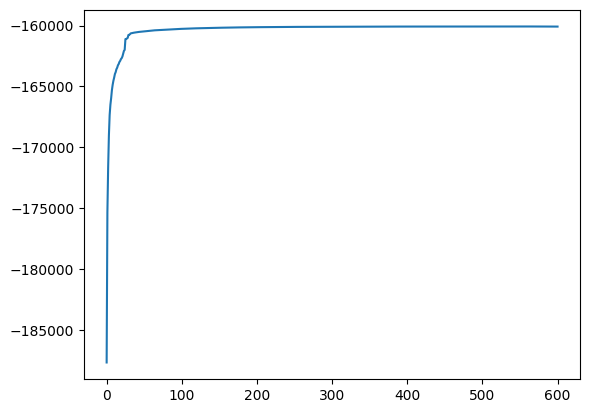

In [43]:
y_lims, list_mod, stats = retirement_prio.fit_type_y(df_stat, N=20, M = 30)

In [48]:
retirement_prio.save_prop(stats.transpose(),list_mod,y_lims, title = 'TAA_propension')

# Assignment model

In [12]:
y_min = 1990
y_max = 2024 #pour le modèle entraîné

ac_ICAO_names = pd.read_csv('D:\p.viry\Documents\Travail_recherche\Travail de Tobias\Technical Data Aircrafts//aircraft_codes_icao_joined.csv', sep = ';')
traff_1 = pd.read_csv('D:\p.viry\Documents\Travail_recherche\Data\data_planes_bts\data_full_airlines\\' + str(y_min) + '\T_T100_SEGMENT_ALL_CARRIER.csv')
for y in range(y_min+1, y_max+1):
    if y%5 == 0 :
        print(y)
    df = pd.read_csv('D:\p.viry\Documents\Travail_recherche\Data\data_planes_bts\data_full_airlines\\' + str(y) + '\T_T100_SEGMENT_ALL_CARRIER.csv')
    traff_1 = pd.concat([traff_1, df], ignore_index=True)
traff_1 = pd.merge(traff_1, ac_ICAO_names[['AIRCRAFT_TYPE', 'ICAO_Code']], on = ['AIRCRAFT_TYPE'])

traff_1.rename(columns = {'ORIGIN_AIRPORT_ID' : 'ADEP','DEST_AIRPORT_ID': 'ADES', 'YEAR':'Period', 'DEPARTURES_PERFORMED': 'N_flights',
                          'AIRCRAFT_TYPE': 'Aircraft Type','ICAO_Code':'Aircraft Type Name', 'UNIQUE_CARRIER' : 'Aircraft Operator','UNIQUE_CARRIER_NAME':'Aircraft Operator Name', 'SEATS': 'Seats'}, inplace = True)  
traff_1 = traff_1[(traff_1['Seats']>0)]
traff_1['DISTANCE'] = traff_1['DISTANCE']*1.852

print('a automatiser dans le module maybe, 1')
# distance_conn = (
#     traff_1.groupby(['ADEP', 'ADES','Period'])
#     .apply(lambda x: (x['Seats'] * x['DISTANCE']).sum() / x['Seats'].sum())
#     .reset_index()
#     .rename(columns={0: 'Distance_conn (km)'})
# )
distance_conn = (pd.concat([g['Seats'].sum().rename('Seats_sum'),
            (traff_1['Seats'] * traff_1['DISTANCE'])
                .groupby([traff_1['ADEP'], traff_1['ADES'], traff_1['Period']])
                .sum()
                .rename('SeatsDist_sum') ],axis=1)
    .assign(**{'Distance_conn (km)': lambda df: df['SeatsDist_sum'] / df['Seats_sum']})
    .reset_index()[['ADEP', 'ADES', 'Period', 'Distance_conn (km)']])

print('2')
seats_conn_p = (
    traff_1.groupby(['ADEP', 'ADES','Period'])['Seats']
    .sum()
    .reset_index()
    .rename(columns={'Seats': 'Seats_conn_p'})
)
print('synthesis...')
traff_1 = pd.merge(
    traff_1,
    distance_conn,
    on=['ADEP', 'ADES','Period'],
    how='left'
)
traff_1 = pd.merge(
    traff_1,
    seats_conn_p,
    on=['ADEP', 'ADES','Period'],
    how='left'
)

traff_1.drop(columns=['PASSENGERS', 'DISTANCE'], inplace = True)
traff_1['ASK_conn_p'] = traff_1['Seats_conn_p']*traff_1['Distance_conn (km)']
traff_1['ASK'] = traff_1['Seats']*traff_1['Distance_conn (km)']
traff_1['ADEP Name'] = traff_1['ADEP'] #a adapter bien sur
traff_1['ADES Name'] = traff_1['ADES'] #a adapter bien sur
print('ok')

1995
2000
2005
2010
2015
2020
a automatiser dans le module maybe, 1
2
synthesis...
ok


In [3]:
traff_2 = pd.read_csv('D:\p.viry\Documents\Travail_recherche\Data\eurocontrol data_archive//flights_market_an_agg.csv')
traff_2.drop(columns=['Unnamed: 0','Siege_ADES', 'Siege_ADEP', 'Siege'], inplace = True)
traff_2['mean_distance'] = traff_2['mean_distance']*1.852
traff_2.rename(columns ={'AC Type':'Aircraft Type', 'AC Operator':'Aircraft Operator', 'echantillon':'Period', 
                         'Taille_f':'Seats', 'tau':'Weight', 'mean_distance':'Distance_conn (km)'}, inplace = True)
seats_conn_p = (
    traff_2.groupby(['ADEP', 'ADES','Period'])['Seats']
    .sum()
    .reset_index()
    .rename(columns={'Seats': 'Seats_conn_p'})
)
traff_2 = pd.merge(
    traff_2,
    seats_conn_p,
    on=['ADEP', 'ADES','Period'],
    how='left'
)

traff_2['Seats_conn_p'] = traff_2['Seats_conn_p']*12
traff_2['ADEP Name']=traff_2['ADEP']
traff_2['ADES Name']=traff_2['ADES']
traff_2['Aircraft Type Name']= traff_2['Aircraft Type']
traff_2['Aircraft Operator Name']=traff_2['Aircraft Operator']
traff_2['ASK'] = traff_2['Seats'] * traff_2['Distance_conn (km)']
traff_2['ASK_conn_p'] = traff_2['Seats_conn_p'] * traff_2['Distance_conn (km)']

In [1]:
print('ajouter la possibilite de fusionner les 2?, dans ce cas ajouter les poids sur bts aussi ?')

ajouter eurocontrol et la possibilite de fusionner les 2


In [122]:
show(ac_ICAO_names)

Loading ITables v2.6.2 from the internet... (need help?)


## Data visualisation

In [16]:
assignment_analysis.market_vis(traff_1[traff_1['Period'].isin([2024])], name_fig = 'market_bts_2024',reso = 400, smooth_param = 0.07, 
                                  market = 'Aircraft Type', observation = 'ASK', dist_limits = [0.8e2, 1.9e4], 
                                  capac_limits = [2e3, 6e6], n_market = 15, period_duration = 1, weight = False)

In [139]:
assignment_analysis.assign_vis(traff_1[traff_1['Period'].isin([1990,1991])], [715], title_fig = '715', name_fig = 'test_assign',reso = 400, smooth_param = 0.07, 
                                  market = 'Aircraft Type', observation = 'ASK', dist_limits = [0.8e2, 1.9e4], 
                                  capac_limits = [2e3, 6e6], vmax = 0.5, period_duration = 1)

In [140]:
assignment_analysis.dynamic_market_vis(traff_1, [i for i in range(1990,2025)], video_name = 'test_market_Type',reso = 400, smooth_param = 0.05, 
                                  market = 'Aircraft Type', observation = 'ASK', dist_limits = [1.5e2, 1.9e4], period_ref = 2024,
                                  capac_limits = [2e3, 6e6], n_market = 18, format='video')

Color choice...
Coloriage trouvé : {626: 0, 622: 1, 694: 2, 819: 3, 655: 4, 627: 5, 619: 6, 614: 7, 698: 8, 612: 9, 696: 10, 817: 11, 625: 12, 699: 11, 637: 12, 715: 13, 620: 14, 732: 15, 873: 16, 624: 13, 882: 14, 640: 9, 740: 17, 616: 18, 687: 15, 887: 16, 816: 7, 730: 8, 617: 19, 629: 17, 675: 19, 760: 5, 888: 6, 889: 13, 634: 18, 673: 4, 638: 17, 359: 18, 693: 10, 631: 15, 722: 3, 691: 16, 721: 17, 838: 19, 765: 18, 608: 14, 690: 2, 733: 17, 710: 16, 697: 10, 874: 14, 839: 1}
0.0%
8.571428571428571%
17.142857142857142%
25.714285714285715%
34.285714285714285%
42.857142857142854%
51.42857142857143%
60.0%
68.57142857142857%
77.14285714285714%
85.71428571428571%
94.28571428571429%


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1400, 1000) to (1408, 1008) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [137]:
assignment_analysis.dynamic_assign_vis(traff_1, [715], [1990,1991,1992,1993,1994], format = 'gif', video_name = '715_assign', market = 'Aircraft Type',
                                       observation = 'ASK', dist_limits = [1.5e2, 1.9e4], capac_limits = [2e3, 6e6],
                                      frame_s = 2, color = 'pink', reso = 400, smooth_param = 0.05, period_duration = 1, vmax = 0.5)

0.0%
60.0%


## Model training

# Productivité des avions

In [4]:
individual_stops = pd.read_csv('D:\p.viry\Documents\Travail_recherche\Data\eurocontrol data_archive//flights_ind_anal.csv')
individual_stops.drop(columns=['Unnamed: 0.1', 'Unnamed: 0','Taille_f', 
                               'Siege_ADES', 'Siege_ADEP', 'Siege', 'Tot siege', 'mean_distance','Actual Distance Flown (nm)'],
                     inplace = True)
individual_stops.rename(columns={'AC Type': 'Aircraft Type', 'AC Operator':'Aircraft Operator','AC Registration':'Aircraft Registration',
                                 'ADES_nf': 'ADES +1', 'ADEP_nf' : 'ADEP +1', 'ADEP_pf': 'ADEP -1', 'ADES_pf': 'ADES -1',
                                'echantillon':'Period','time_delta': 'Real Flight Duration', 'time_delta2':'Planned Flight Duration',
                                'time_delta_nf': 'Real Flight Duration +1', 'time_delta2_nf':'Planned Flight Duration +1',
                                 'time_delta_pf': 'Real Flight Duration -1', 'time_delta2_pf':'Planned Flight Duration -1',
                                 'delta_flights' : 'Ground Time', 'delta_pre_flights' : 'Ground Time -1'}, inplace = True)

In [2]:
flights_streaks = pd.read_csv('D:\p.viry\Documents\Travail_recherche\Data\eurocontrol data_archive//flights_long_anal.csv')
flights_streaks['FILED OFF BLOCK TIME'] = pd.to_datetime(flights_streaks['FILED OFF BLOCK TIME'], utc=True).dt.tz_localize(None)
flights_streaks['FILED ARRIVAL TIME'] = pd.to_datetime(flights_streaks['FILED ARRIVAL TIME'], utc=True).dt.tz_localize(None)
flights_streaks['FILED OFF BLOCK TIME'] = pd.to_datetime(flights_streaks['ACTUAL OFF BLOCK TIME'], utc=True).dt.tz_localize(None)
flights_streaks['FILED ARRIVAL TIME'] = pd.to_datetime(flights_streaks['ACTUAL ARRIVAL TIME'], utc=True).dt.tz_localize(None)
flights_streaks.drop(columns=['Unnamed: 0.2','Unnamed: 0.1', 'Unnamed: 0','Taille_f', 'ADES_nf', 'ADEP_nf',
                              'ADEP_pf', 'ADES_pf','time_delta','time_delta2', 'time_delta_nf', 'time_delta2_nf',
                                 'time_delta_pf', 'time_delta2_pf','delta_flights' , 'delta_pre_flights',
                               'Siege_ADES', 'Siege_ADEP', 'Siege', 'Tot siege', 'mean_distance','Actual Distance Flown (nm)'],
                     inplace = True)
flights_streaks.rename(columns={'AC Type': 'Aircraft Type', 'AC Operator':'Aircraft Operator','AC Registration':'Aircraft Registration',
                                'echantillon':'Period'}, inplace = True)

In [2]:
traff_2 = pd.read_csv('D:\p.viry\Documents\Travail_recherche\Data\eurocontrol data_archive//flights_market_an_agg.csv')

In [13]:
flights_streaks[flights_streaks['Actual Distance Flown (nm)']<1500/1.852].shape
flights_streaks[flights_streaks['Actual Distance Flown (nm)']>4000/1.852].shape
flights_streaks[(flights_streaks['Actual Distance Flown (nm)']>1500/1.852)&(individual_stops['Actual Distance Flown (nm)']<4000/1.852)].shape
flights_streaks[['Actual Distance Flown (nm)','AC Registration','echantillon']].groupby(['AC Registration','echantillon']).count()
flights_streaks[['Actual Distance Flown (nm)','AC Registration']].groupby(['AC Registration']).count().

(542529, 32)

## Data visualisation individual stops

In [98]:
productivity_analysis.GT_density(individual_stops, name_fig = 'GT_density_2',sigma = 0.005, reso = 1000)

In [5]:
productivity_analysis.TATs_matrix(individual_stops, name_fig= 'Full_df', reso = 1000, sigma = 0.015)

5.4% are not b&f flights


## Data visualisation flight streaks

In [45]:
aircraft_ex = flights_streaks[(flights_streaks['Aircraft Registration']=='FGZNR')&(flights_streaks['Period']==17)] #B77w
x_min = productivity_analysis.visu_distrib(aircraft_ex, titre = 'hour_distrib_B77W', visu = True, visu_c = True)[0]
productivity_analysis.visu(aircraft_ex, titre = 'B77W', visu = True, x_min = x_min)


In [24]:
L_NB = ['B738', 'A320', 'A319', 'A20N', 'A321', 'A21N', 'B38M', 'B752','B737',  'B739','A318',
        'B712','B733','B736','B735','B753','MD11','MD82','B39M','B734'] #NB classiques
LC = ['RYR', 'EZY', 'WZZ', 'VLG']
LL = ['AFR', 'KLM', 'BAW', 'DLH', 'SAS', 'TAP', 'IBE', 'SWR']
selec = flights_streaks[(flights_streaks['Aircraft Operator'].isin(LC))&(flights_streaks['Aircraft Type'].isin(L_NB))&(flights_streaks['Period']<20)
    &((flights_streaks['Period']%4 == 1)|(flights_streaks['Period']%4 == 2))]
flight_grouping = productivity_analysis.constru_flight_streak(selec)
productivity_analysis.visu_flight_streaks(flight_grouping,title = 'regimes_lc', min_fh = 0.5, 
                                          max_fh = 6,reso = 400, sigma = 0.02, n_s = 2)

0%, 5%, 10%, 15%, 20%, 25%, 30%, 35%, 40%, 45%, 50%, 55%, 60%, 65%, 70%, 75%, 80%, 85%, 90%, 95%, 100%, 100 %, ok.
1, 2, 3, 4, 5, 6, 7, 8, 9, 10, ok.


In [26]:
selec = flights_streaks[(flights_streaks['Period']<20)]
flight_grouping = productivity_analysis.constru_flight_streak(selec)
productivity_analysis.visu_flight_streaks(flight_grouping,title = 'regimes_all', min_fh = 0.5, 
                                          max_fh = 14,reso = 400, sigma = 0.01, n_s = 3)

0%, 5%, 10%, 15%, 20%, 25%, 30%, 35%, 40%, 45%, 50%, 55%, 60%, 65%, 70%, 75%, 80%, 85%, 90%, 95%, 100%, 100 %, ok.
1, 2, 3, 4, 5, 6, 7, 8, 9, 10, ok.


In [27]:
flight_grouping_2 = flight_grouping[flight_grouping[:,1]/flight_grouping[:,3]>0]
productivity_analysis.streaks_matrix(flight_grouping_2,title = 'streak_matrix_all', min_fh = 0.5, 
                                          max_fh = 14,reso = 1000, sigma = 0.02)

## Model training